# Handling Outliers

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [51]:
# this csv is obtained from the previous notebook of 26Apr, 26-04-2026_AIEdited_And_Notes
df_Drop_manyMissing_lowCorrWithTarget_MultiColl = pd.read_csv("Drop_manyMissing_lowCorrWithTarget_MultiColl.csv")
df_Drop_manyMissing_lowCorrWithTarget_MultiColl.head()

,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,...,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,ScreenPorch,SaleType,SaleCondition,SalePrice
0,RL,65.0,8450,Pave,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,...,TA,TA,Y,0,61,0,0,WD,Normal,208500
1,RL,80.0,9600,Pave,Reg,Lvl,AllPub,FR2,Gtl,Veenker,...,TA,TA,Y,298,0,0,0,WD,Normal,181500
2,RL,68.0,11250,Pave,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,...,TA,TA,Y,0,42,0,0,WD,Normal,223500
3,RL,60.0,9550,Pave,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,...,TA,TA,Y,0,35,272,0,WD,Abnorml,140000
4,RL,84.0,14260,Pave,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,...,TA,TA,Y,192,84,0,0,WD,Normal,250000


In [52]:
df = df_Drop_manyMissing_lowCorrWithTarget_MultiColl

A boxplot shows the distribution of a numeric variable:
- the central line is the median
- the box spans the 1st quartile (Q1) to the 3rd quartile (Q3)
- the box height is the interquartile range (IQR)
- whiskers extend to the most extreme points within 1.5 × IQR from the quartiles
- points beyond the whiskers are shown as outliers

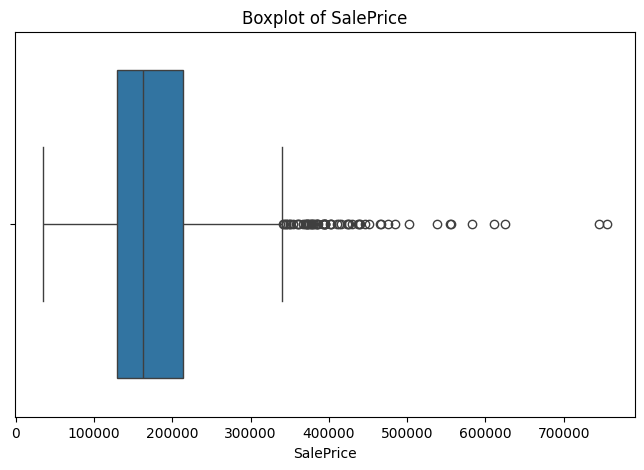

In [7]:
# Visualizing Outliers

plt.figure(figsize=(8,5))
sns.boxplot(x=df["SalePrice"])
plt.title("Boxplot of SalePrice")
plt.show()

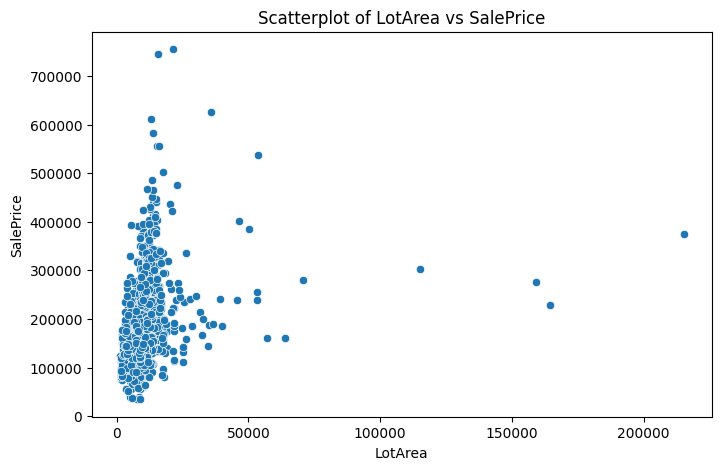

In [8]:
# Scatter plot LotArea vs SalePrice
plt.figure(figsize=(8,5))
sns.scatterplot(x=df["LotArea"], y=df["SalePrice"])
plt.title("Scatterplot of LotArea vs SalePrice")
plt.show()

In [9]:
# Assigment : 
# Find important features
# all important feature scatter plot w.r.t saleprice

# IQR method (Interquartile Range)

#### outliers = values outside [Q1 - 1.5xIQR , Q3 + 1.5xIQR]

- The IQR (Interquartile Range) method identifies outliers using the middle 50% of your data. It is calculated as IQR = Q3 - Q1, where Q3 is the 75th percentile and Q1 is the 25th percentile. Outliers are points that fall below Q1 - 1.5 × IQR or above Q3 + 1.5 × IQR.

- Pros

    Resilient to extreme values: Unlike standard deviation, IQR uses percentiles, meaning extreme outliers do not skew the results.

    Distribution-free: It does not assume your data follows a normal bell curve.

    Easy to compute: It is simple to understand and straightforward to code using tools like Python Pandas.

- Cons
    
    Can remove valid data: In real-world data (especially skewed or heavy-tailed data), mathematically flagged outliers may actually be valid, meaningful data points.
    
    Loss of sample size: Deleting rows permanently reduces your dataset.
    
    Univariate limitation: It only evaluates one variable at a time, missing multidimensional outliers (e.g., a normal height and normal weight that do not make sense together).

- When to Use

    Heavily skewed data: When your dataset is not normally distributed, IQR is more effective than statistical tests based on mean and standard deviation.
    
    Before training models: Use it to remove data entry errors (like a person's height recorded as 40 feet) before building machine learning models.
    
    Exploratory Data Analysis (EDA): Use it in early data cleaning phases to quickly visualize or filter extreme noise.

In [10]:
import numpy

In [16]:
def detect_outliers(data, col):
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3-Q1
    lower_fence = Q1 - 1.5 * IQR
    upper_fence = Q3 + 1.5 * IQR
    outliers = data[(data[col] < lower_fence) | (data[col] > upper_fence)]
    return outliers[col].to_frame() 

#outliers[[col]]-- it also return a dataframe and not a series

In [17]:
outliers_saleprice = detect_outliers(df, "SalePrice")
outliers_saleprice

,SalePrice
11,345000
53,385000
58,438780
112,383970
151,372402
...,...
1268,381000
1353,410000
1373,466500
1388,377500


In [18]:
print(f"No. of outliers in SalePrice : {len(outliers_saleprice)}")
display(outliers_saleprice.head())

No. of outliers in SalePrice : 61


,SalePrice
11,345000
53,385000
58,438780
112,383970
151,372402


In [90]:
# how to check if data is normally distributed

 - Checking for a normal distribution means checking if your data looks like a symmetrical, bell-shaped curve. You can do this by using visual graphs (like histograms) or numbers (statistical tests). In the real world, experts use a mix of both to be sure.

- Visual Checks (Look at the data)Visual methods give you a quick picture of your data's shape.

    Histogram: A bar chart of your data. If it looks like a bell with the highest point in the center, your data might be normal.
    
    Q-Q Plot (Quantile-Quantile Plot): Compares your data to a perfect normal line. If the dots form a straight diagonal line, the data is normal.
    
    Box Plot: Shows the median and how spread out the data is. For normal data, the box is in the middle, and the "whiskers" are even on both sides.

- Statistical Tests (Math formulas)These tests look at numbers and give you a p-value. A p-value is a number between 0 and 1.If your p-value is less than 0.05, the data is not normal.If your p-value is greater than 0.05, the data is normal.Here are the most common tests:

    Shapiro-Wilk Test: The best and most used test for small to medium datasets. It is highly accurate.
    
    Kolmogorov-Smirnov (KS) Test: Compares your data's actual spread to a normal spread. Use this for very large datasets.
    
    Anderson-Darling Test: Like the KS test, but it checks if the ends (tails) of your bell curve match the normal curve.

- Number Rules (Quick checks)These are quick math rules you can do without a computer.

    Skewness: Measures how lopsided your data is. For a normal distribution, the skewness is exactly 0.

    Kurtosis: Measures if data peaks too high or too flat. For a normal distribution, the kurtosis is exactly 3 (or 0 in some software).
    
    Rule of Thumb: If your skewness and kurtosis are between -1 and +1, your data is "normal enough" for most tests.

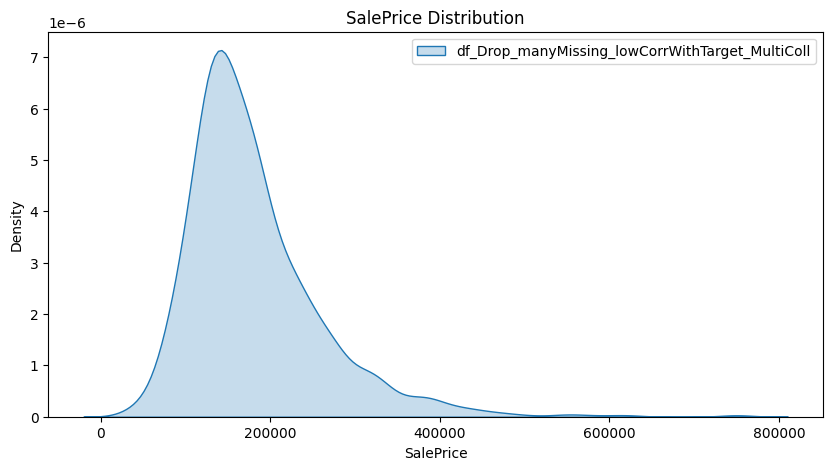

In [19]:
plt.figure(figsize=(10,5))
# kdeplot --> plot that shows pdf
sns.kdeplot(df["SalePrice"], label="df_Drop_manyMissing_lowCorrWithTarget_MultiColl", fill=True)
plt.legend()
plt.title("SalePrice Distribution")
plt.show()

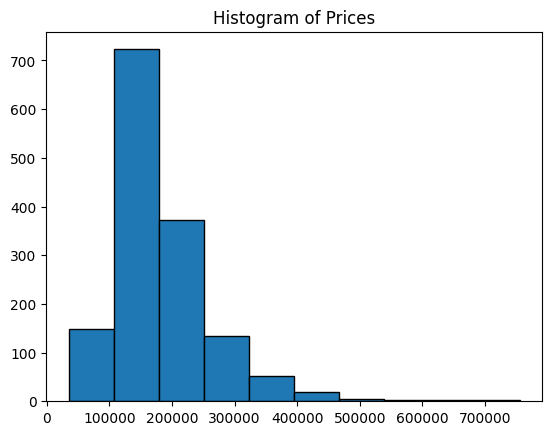

In [20]:
plt.hist(df['SalePrice'], bins=10, edgecolor='black')
plt.title("Histogram of Prices")
plt.show()

In [21]:
import scipy.stats as stats

- A Q-Q plot (Quantile-Quantile plot) is a visual tool used to check if your data fits a specific type of probability distribution (like a normal or "bell curve" distribution). It compares the values you actually have (your data) with the values you would expect to see if your data perfectly matched that distribution.

- How it is drawn:To create a standard Q-Q plot, you do the following steps:

    Sort the data: Arrange your data points from smallest to largest.

    Assign probabilities: Give each sorted point a specific probability rank. For n data points, the rank for the i-th point is often calculated as p_i = {i - 0.5}/n.

    Find theoretical quantiles: Using the chosen distribution (like the normal curve), calculate the exact values expected at those same probabilities.
    
    Plot the points: Make a scatterplot with the theoretical expected values on the horizontal axis and your actual data values on the vertical axis.

- How to read it:

    The Reference Line: A straight 45-degree line is drawn through the plot. If your dots line up perfectly on this line, your data matches the distribution.
    
    Curves (Skew): If the dots curve in an "S" shape or a banana shape, your data has skewness (it is lopsided).
    
    Bends at the ends: If the points line up in the middle but stray from the line at the very top or bottom, your data has "heavy" or "light" tails (more or fewer extreme outliers than expected)

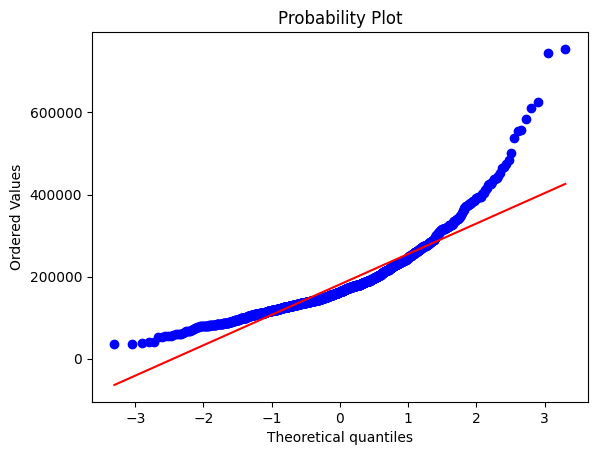

In [22]:
# Q-Q Plot

# if points follow a diagonal line,data is normal
stats.probplot(df['SalePrice'], dist="norm", plot=plt)
plt.show()

#### Shapiro-Wilk Test -> Normal or not

In [23]:
# Shapiro-Wilk Test -> Normal or not
alpha = 0.05
# H0 is : Data is normal
# H1 : Otherwise


stat, p = stats.shapiro(df['SalePrice'])
print("Shapiro-Wilk Test p-value:", p)
if p > alpha:
    print("Data looks normal")
else:
    print("Data is NOT normal")

# 95% -> 5% error
# 99% -> 1% error

Shapiro-Wilk Test p-value: 3.2061412312021656e-33
Data is NOT normal


#### Z stats to check for outliers

In [53]:
from scipy.stats import zscore

In [54]:
df["SalePrice_z"] = zscore(df["SalePrice"]) # add a new column for z score of SalePrice
outliers_z = df[df["SalePrice_z"].abs() > 3]
outliers_z

,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,...,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,ScreenPorch,SaleType,SaleCondition,SalePrice,SalePrice_z
58,RL,66.0,13682,Pave,IR2,HLS,AllPub,CulDSac,Gtl,StoneBr,...,TA,Y,192,0,37,0,New,Partial,438780,3.246967
178,RL,63.0,17423,Pave,IR1,Lvl,AllPub,CulDSac,Gtl,StoneBr,...,TA,Y,0,60,0,0,New,Partial,501837,4.040982
185,RM,90.0,22950,Pave,IR2,Lvl,AllPub,Inside,Gtl,OldTown,...,TA,Y,0,260,0,410,WD,Normal,475000,3.703050
349,RL,56.0,20431,Pave,IR2,Lvl,AllPub,Inside,Gtl,NridgHt,...,TA,Y,0,0,0,0,New,Partial,437154,3.226492
389,RL,96.0,12474,Pave,Reg,Lvl,AllPub,Inside,Gtl,NridgHt,...,TA,Y,196,134,0,0,New,Partial,426000,3.086040
440,RL,105.0,15431,Pave,Reg,Lvl,AllPub,Inside,Gtl,NridgHt,...,TA,Y,0,72,0,170,WD,Normal,555000,4.710413
473,RL,110.0,14977,Pave,IR1,Lvl,AllPub,Inside,Gtl,NridgHt,...,TA,Y,250,63,0,0,New,Partial,440000,3.262329
496,RL,NaN,12692,Pave,IR1,Lvl,AllPub,Inside,Gtl,NoRidge,...,TA,Y,264,75,291,0,WD,Normal,430000,3.136409
527,RL,67.0,14948,Pave,IR1,Lvl,AllPub,Inside,Gtl,NridgHt,...,TA,Y,126,66,0,0,New,Partial,446261,3.341168
591,RL,97.0,13478,Pave,IR1,Lvl,AllPub,Corner,Gtl,NridgHt,...,TA,Y,382,274,0,0,ConLI,Normal,451950,3.412804


In [55]:
print(f"Number of outliers in SalePrice (Z-score): {len(outliers_z)}")
outliers_z[["SalePrice", "SalePrice_z"]].head()

Number of outliers in SalePrice (Z-score): 22


,SalePrice,SalePrice_z
58,438780,3.246967
178,501837,4.040982
185,475000,3.703050
349,437154,3.226492
389,426000,3.086040


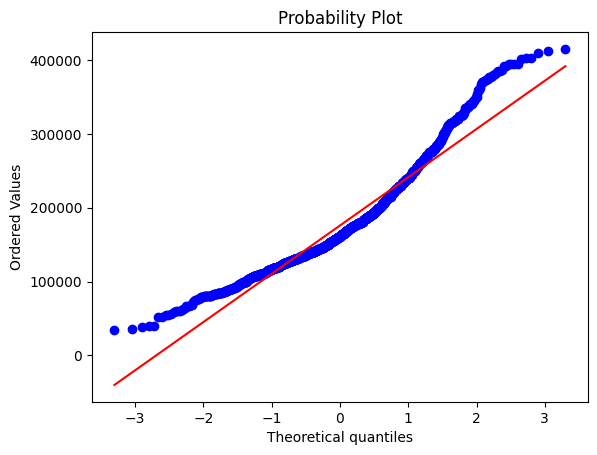

In [56]:
# QQ PLot without outliers in SalePrice

without_outliers_z = df[df["SalePrice_z"].abs() <= 3]
stats.probplot(without_outliers_z['SalePrice'], dist="norm", plot=plt)
plt.show()

#### Modified Z Score

- The Median Absolute Deviation (MAD) is a robust, outlier-resistant statistical measure of data variability. Unlike the standard deviation, it is highly tolerant to extreme values and skewed data.

- The CalculationTo find the MAD, calculate the median of the absolute differences between each data point and the dataset's median:
    
    MAD = median(X_{i}-median(X))

- Why use MAD?

    Robustness: Standard variance and mean absolute deviation are heavily skewed by extreme outliers, whereas the median heavily dampens their effect.
    
    Anomaly Detection: Because of its resistance to outliers, MAD is widely used for anomaly detection in time series data, identifying data points that "deviate from the pack".
    
    Consistency: For a normal (Gaussian) distribution, the MAD is related to the standard deviation by a scaling factor of roughly 1.4826. For practical purposes, Scaled MAD = 1.4826 × MAD estimates the standard deviation of normal data accurately while maintaining robustness.

        In simple terms, consistency is just a way to make the MAD "match" the Standard Deviation when you're looking at a normal, bell-curve distribution.Think of it like converting currency:

        The Measurement Gap
        
            The Median Absolute Deviation (MAD) and Standard Deviation (SD) measure the same thing—how spread out your data is—but they use different "rulers.

                "On a perfect bell curve, the raw MAD is always smaller than the Standard Deviation.
                
                Specifically, the MAD only covers about 67% of the area that one Standard Deviation covers.
            
        The "Exchange Rate" (1.4826)
        
            To make them equal, we use a magic number: 1.4826.
            
            If you take your MAD and multiply it by 1.4826, you get a "Scaled MAD."This Scaled MAD will be almost exactly the same as your Standard Deviation if your data is normal.

        Why bother?
        
            We do this because the Standard Deviation is the "gold standard" in most math, but it's easily broken by one or two huge outliers (like adding a billionaire's salary to a room of average earners).
            
            The Goal: You want the toughness of the Median (it ignores the billionaire) but the familiarity of the Standard Deviation to continue using it.
            
            The Solution: Calculate the MAD, multiply by 1.4826, and you have a "tough" version of the Standard Deviation that isn't tricked by outliers

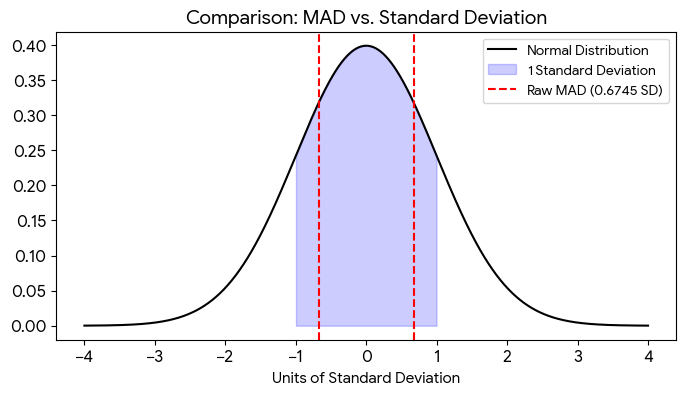

As shown above, the Raw MAD (red lines) is naturally narrower than 1 Standard Deviation (blue area). Multiplying by 1.4826 stretches those red lines out to perfectly match the edges of the blue area

In [57]:
from scipy.stats import median_abs_deviation

In [58]:
mad = median_abs_deviation(df["SalePrice"])
mad

np.float64(38000.0)

In [59]:
median = df["SalePrice"].median()
mad = median_abs_deviation(df["SalePrice"])
cons_m_zscore = 0.6745

df["SalePrice_modified_z"] = (df["SalePrice"] - median) / (mad/cons_m_zscore)
# (mad/cons_m_zscore) is converting to the standard deviation equivalent for the modified z-score
# 1/cons_m_zscore is converting to the standard deviation equivalent for the modified z-score = 1.4826

outliers_modified_z = df[df["SalePrice_modified_z"].abs() > 3.5]

In [60]:
print(f"Number of outliers(Modified Z-score) in SalePrice : {len(outliers_modified_z)}")
outliers_modified_z[["SalePrice", "SalePrice_z", "SalePrice_modified_z"]].head()

Number of outliers(Modified Z-score) in SalePrice : 51


,SalePrice,SalePrice_z,SalePrice_modified_z
53,385000,2.569767,3.940500
58,438780,3.246967,4.895095
112,383970,2.556797,3.922217
151,372402,2.411133,3.716886
161,412500,2.916048,4.428625


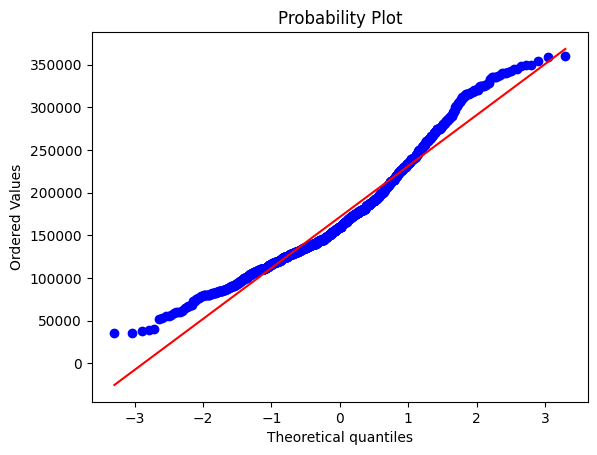

In [62]:
# QQ PLot without outliers in SalePrice (Z-score mod)

without_outliers_z_modified = df[df["SalePrice_modified_z"].abs() <= 3.5]
stats.probplot(without_outliers_z_modified['SalePrice'], dist="norm", plot=plt)
plt.show()

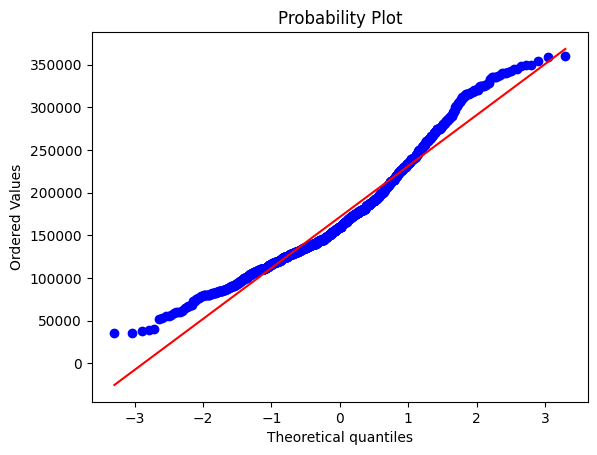

In [ ]:
# QQ PLot without outliers in SalePrice (Z-score mod v2)
# same thing as above, rather than using abs() function, we can use the range of values to filter the data
lower = -3.5
higher = 3.5
without_outliers_z_mod_v2 = df[(df["SalePrice_modified_z"] >= lower) & (df["SalePrice_modified_z"] <= higher)]
stats.probplot(without_outliers_z_mod_v2['SalePrice'], dist="norm", plot=plt)
plt.show()

#### Winsorization

- Winsorization is a statistical data-cleaning technique used to handle outliers (extreme data points). Instead of deleting these values entirely, Winsorization caps them by replacing extreme high and low values with the nearest non-extreme values from the same dataset.For example, if you Winsorize the top and bottom 5% of a dataset, all data below the 5th percentile is set to the 5th percentile value, and all data above the 95th percentile is set to the 95th percentile value.

- Pros of Winsorization
    
    Keeps all data points: You do not lose valuable sample size or statistical power by deleting rows.
    
    Reduces skewness: It stops extreme anomalies from ruining your average and standard deviation.
    
    Safeguards against bad data: It minimizes the impact of human typing errors (e.g., adding an extra zero to a number).

- Cons of Winsorization

    Alters the data: You are actively changing recorded numbers, which can slightly shift your data's true distribution.
    
    Hides real insights: If the extreme values are actually important discoveries (e.g., a massive spike in sales), capping them removes that vital information.
    
    Requires arbitrary thresholds: Choosing to cap at 1%, 5%, or 10% depends on judgment, which can introduce bias.

- When to Use It

    Use it when you are running automated processes and cannot manually inspect every outlier in your data.

    Use it when outliers are distorting your results, but you still want to retain your sample size.

    Use it when you suspect extreme values are mistakes or random noise, rather than valuable rare events.

In [31]:
# Winsorization (Capping Extreme Values)
# Instead of deleting outliers, we cap them to a limit.

In [ ]:
# !pip install feature_engine

In [33]:
from feature_engine.outliers import Winsorizer

In [41]:
winsor = Winsorizer(capping_method="quantiles", tail="both", fold=0.05, variables=["SalePrice"])
winsor

,capping_method,'quantiles'
,tail,'both'
,fold,0.05
,variables,['SalePrice']
,add_indicators,False
,missing_values,'raise'


In [42]:
# winsor.fit_transform(df)
# - `fit` computes the capping thresholds from the dataframe based on the selected variable(s).
#   For `SalePrice` with fold=0.05, it finds the 5th and 95th percentiles.
# - `transform` then replaces values below the 5th percentile with the 5th percentile value,
#   and values above the 95th percentile with the 95th percentile value.
# - The returned dataframe has the same rows and columns, but extreme SalePrice values are capped.

df_winsor_explained = winsor.fit_transform(df)

original_q05 = df["SalePrice"].quantile(0.05)
original_q95 = df["SalePrice"].quantile(0.95)

print("Original SalePrice 5th percentile:", original_q05)
print("Original SalePrice 95th percentile:", original_q95)
print("Original SalePrice min/max:", df["SalePrice"].min(), df["SalePrice"].max())
print("Winsorized SalePrice min/max:", df_winsor_explained["SalePrice"].min(), df_winsor_explained["SalePrice"].max())

Original SalePrice 5th percentile: 88000.0
Original SalePrice 95th percentile: 326099.9999999999
Original SalePrice min/max: 34900 755000
Winsorized SalePrice min/max: 88000.0 326099.9999999999


In [43]:

df_winsor = winsor.fit_transform(df)
df_winsor

,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,...,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,ScreenPorch,SaleType,SaleCondition,SalePrice
0,RL,65.0,8450,Pave,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,...,TA,TA,Y,0,61,0,0,WD,Normal,208500.0
1,RL,80.0,9600,Pave,Reg,Lvl,AllPub,FR2,Gtl,Veenker,...,TA,TA,Y,298,0,0,0,WD,Normal,181500.0
2,RL,68.0,11250,Pave,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,...,TA,TA,Y,0,42,0,0,WD,Normal,223500.0
3,RL,60.0,9550,Pave,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,...,TA,TA,Y,0,35,272,0,WD,Abnorml,140000.0
4,RL,84.0,14260,Pave,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,...,TA,TA,Y,192,84,0,0,WD,Normal,250000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,RL,62.0,7917,Pave,Reg,Lvl,AllPub,Inside,Gtl,Gilbert,...,TA,TA,Y,0,40,0,0,WD,Normal,175000.0
1456,RL,85.0,13175,Pave,Reg,Lvl,AllPub,Inside,Gtl,NWAmes,...,TA,TA,Y,349,0,0,0,WD,Normal,210000.0
1457,RL,66.0,9042,Pave,Reg,Lvl,AllPub,Inside,Gtl,Crawfor,...,TA,TA,Y,0,60,0,0,WD,Normal,266500.0
1458,RL,68.0,9717,Pave,Reg,Lvl,AllPub,Inside,Gtl,NAmes,...,TA,TA,Y,366,0,112,0,WD,Normal,142125.0


In [44]:
# manual calculation
# Calculate the 5th and 95th percentiles
percentile_5 = df["SalePrice"].quantile(0.05)
percentile_95 = df["SalePrice"].quantile(0.95)

print(f"5th percentile of SalePrice: {percentile_5}")
print(f"95th percentile of SalePrice: {percentile_95}")

5th percentile of SalePrice: 88000.0
95th percentile of SalePrice: 326099.9999999999


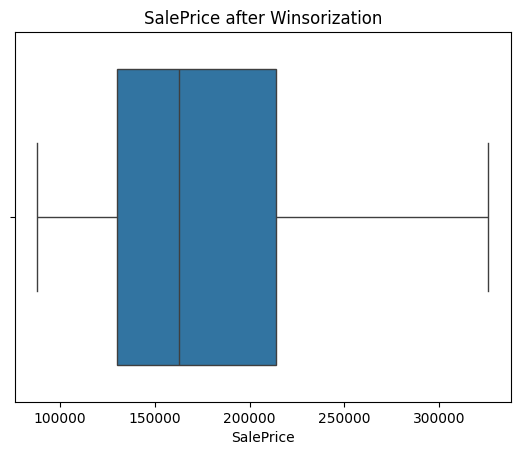

In [45]:
sns.boxplot(x=df_winsor["SalePrice"])
plt.title("SalePrice after Winsorization")
plt.show()

In [46]:
def compare_outliers(original_df, modified_df, column):
    plt.figure(figsize=(12,5))
    plt.subplot(1,2,1)
    sns.boxplot(x=original_df[column])
    plt.title(f"{column} - Before")

    plt.subplot(1,2,2)
    sns.boxplot(x=modified_df[column])
    plt.title(f"{column} - After")
    
    plt.show()

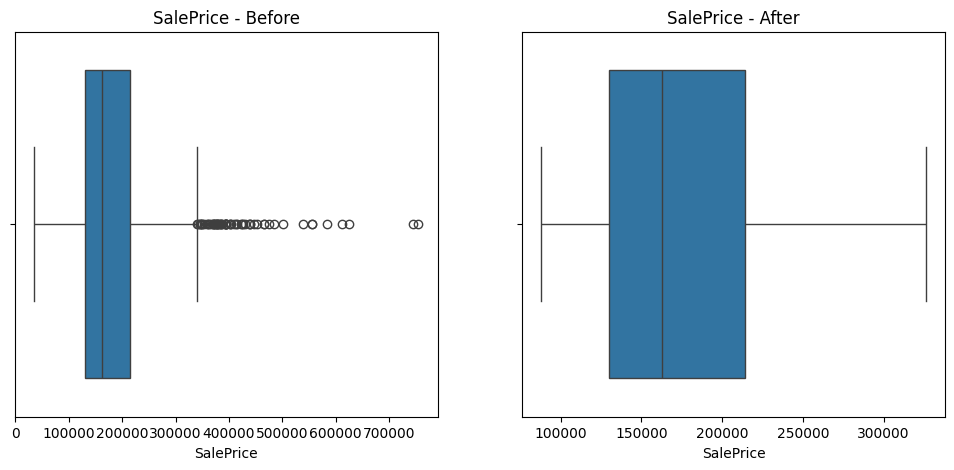

In [47]:
compare_outliers(df, df_winsor, "SalePrice")